# 07 — Exact OU propagation and numerical certification

Numerical-methods companion. It implements the exact finite-step Ornstein–Uhlenbeck update, checks stationarity and analytical moments, compares Monte Carlo ensembles with exact predictions, and demonstrates why coarse Euler–Maruyama stepping can distort the dynamics.


## Guiding question
How can Ornstein–Uhlenbeck simulations be checked against exact propagation without confusing time-discretization error with physics?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, solve_continuous_lyapunov
np.set_printoptions(precision=6, suppress=True)


For $\mathrm dX=AX\,\mathrm dt+B\,\mathrm dW$, define
$$
\Phi=e^{A\Delta t},\qquad
Q_{\Delta t}=\int_0^{\Delta t}e^{As}De^{A^Ts}\,\mathrm ds.
$$
When $\Sigma_b$ is stationary, the integral is exactly
$$
Q_{\Delta t}=\Sigma_b-\Phi\Sigma_b\Phi^T.
$$
Then $X_{n+1}=\Phi X_n+\eta_n$ with $\eta_n\sim\mathcal N(0,Q_{\Delta t})$ is exact at the sampled times.


In [2]:
rng=np.random.default_rng(20260916)
L=0.100; C=100e-6; R=110.; kBT=1.0
A=np.array([[0.,1.],[-1/(L*C),-R/L]])
G=np.diag([1/C,L]); Sigma_b=kBT*np.linalg.inv(G)
dt=5e-4
Phi=expm(A*dt); Q=Sigma_b-Phi@Sigma_b@Phi.T
assert np.min(np.linalg.eigvalsh(Q))>-1e-12
# exact stationarity identity
assert np.allclose(Phi@Sigma_b@Phi.T+Q,Sigma_b)
print('exact discrete covariance identity: PASS')


exact discrete covariance identity: PASS


## Monte Carlo validation from a nonstationary Gaussian preparation


In [3]:
Nens=12000; nsteps=60
mu0=np.array([2e-3,0.0]); S0=1.8*Sigma_b
X=rng.multivariate_normal(mu0,S0,size=Nens)
means=[X.mean(0)]; covs=[np.cov(X,rowvar=False,ddof=1)]
# Positive-semidefinite square root of the exact discrete covariance.
# This avoids adding an arbitrary diagonal jitter to quantities with different SI units.
qe, qv=np.linalg.eigh(0.5*(Q+Q.T))
LQ=qv@np.diag(np.sqrt(np.clip(qe,0.0,None)))
for _ in range(nsteps):
    X=X@Phi.T+rng.standard_normal((Nens,2))@LQ.T
    means.append(X.mean(0)); covs.append(np.cov(X,rowvar=False,ddof=1))
means=np.array(means); covs=np.array(covs)
ts=np.arange(nsteps+1)*dt
mean_exact=[]; cov_exact=[]
for tt in ts:
    P=expm(A*tt); mean_exact.append(P@mu0); cov_exact.append(Sigma_b+P@(S0-Sigma_b)@P.T)
mean_exact=np.array(mean_exact); cov_exact=np.array(cov_exact)
# q and I have different units and equilibrium scales, so evaluate sampling error in
# thermal-standard-deviation coordinates rather than with a dimensionally mixed norm.
Sscale=np.diag(np.sqrt(np.diag(Sigma_b)))
Sinv=np.linalg.inv(Sscale)
mean_err=np.array([np.linalg.norm(Sinv@(means[i]-mean_exact[i])) for i in range(len(ts))])
cov_err=np.array([np.linalg.norm(Sinv@(covs[i]-cov_exact[i])@Sinv,ord='fro') for i in range(len(ts))])
print('max standardized mean error =',mean_err.max())
print('max standardized covariance Frobenius error =',cov_err.max())
# For N=12000 these bounds are deliberately several sampling standard errors wide.
assert mean_err.max()<0.08
assert cov_err.max()<0.10


max standardized mean error = 0.022925590451973624
max standardized covariance Frobenius error = 0.05932386232968979


## Exact update versus coarse Euler–Maruyama


exact-step mean error = 0.0 Euler mean error = 0.025676013729957706


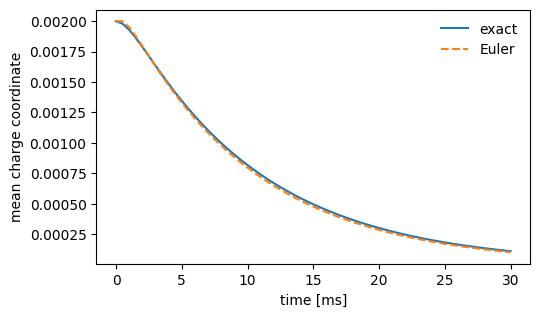

In [4]:
# deterministic mean comparison isolates time-discretization bias cleanly
mu_exact=np.array([expm(A*tt)@mu0 for tt in ts])
mu_em=[mu0.copy()]
M=np.eye(2)+A*dt
for _ in range(nsteps): mu_em.append(M@mu_em[-1])
mu_em=np.array(mu_em)
err_exact=np.max(np.linalg.norm(mean_exact-mu_exact,axis=1))
err_em=np.max(np.linalg.norm(mu_em-mu_exact,axis=1))
print('exact-step mean error =',err_exact,'Euler mean error =',err_em)
assert err_exact<1e-12 and err_em>1e-6
fig,ax=plt.subplots(figsize=(5.6,3.3)); ax.plot(1e3*ts,mu_exact[:,0],label='exact'); ax.plot(1e3*ts,mu_em[:,0],'--',label='Euler'); ax.set(xlabel='time [ms]',ylabel='mean charge coordinate'); ax.legend(frameon=False); plt.show()


## Grid-refined crossing detection
For sampled energy curves, locate the first sign change of $\Delta E=E_f-E_s$ and linearly interpolate inside that bracket. Refining the sample grid should converge to the analytical crossing rather than moving it systematically.


In [5]:
def first_crossing(t,y):
    s=np.sign(y)
    idx=np.where(s[:-1]*s[1:]<=0)[0]
    if len(idx)==0: return np.nan
    i=idx[0]
    return t[i]-y[i]*(t[i+1]-t[i])/(y[i+1]-y[i])
ls=-100.; lf=-1000.; Es0=1.; Ef0=10.
true=np.log(Es0/Ef0)/(2*(lf-ls))
for h in [4e-4,2e-4,1e-4,5e-5]:
    tg=np.arange(0,0.01+h,h); y=Ef0*np.exp(2*lf*tg)-Es0*np.exp(2*ls*tg)
    est=first_crossing(tg,y); print(h,est,abs(est-true))
assert abs(first_crossing(np.arange(0,.01+5e-5,5e-5), Ef0*np.exp(2*lf*np.arange(0,.01+5e-5,5e-5))-Es0*np.exp(2*ls*np.arange(0,.01+5e-5,5e-5)))-true)<2e-6


0.0004 0.0013098223897506473 3.060844919839994e-05
0.0002 0.001289885188391755 1.0671247839507672e-05
0.0001 0.0012809791873158026 1.7652467635552622e-06
5e-05 0.0012798793427750822 6.654022228348537e-07


## Reader exploration
1. Repeat the Euler–Maruyama comparison for several time steps and plot its convergence toward the exact update. 2. Increase and decrease the Monte Carlo ensemble size and verify the expected reduction of standardized sampling error.
